# Healthcare Patient Segmentation — EDA & Clustering

This notebook explores the raw patient dataset and works through the clustering
approach used in the production pipeline (`src/`). It's meant for exploration
and explaining *why* the pipeline is built the way it is, not for running in
production — the actual pipeline lives in the `src/` scripts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the raw data

In [2]:
df = pd.read_csv("../data/raw/patient_segmentation_dataset.csv")
print(df.shape)
df.head()

(2000, 16)


,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2000 non-null   str    
 1   Age                     2000 non-null   int64  
 2   Gender                  2000 non-null   str    
 3   State                   2000 non-null   str    
 4   City                    2000 non-null   str    
 5   Height_cm               2000 non-null   int64  
 6   Weight_kg               2000 non-null   int64  
 7   BMI                     2000 non-null   float64
 8   Insurance_Type          2000 non-null   str    
 9   Primary_Condition       1505 non-null   str    
 10  Num_Chronic_Conditions  2000 non-null   int64  
 11  Annual_Visits           2000 non-null   int64  
 12  Avg_Billing_Amount      2000 non-null   float64
 13  Last_Visit_Date         2000 non-null   str    
 14  Days_Since_Last_Visit   2000 non-null   int64  
 15

## 2. Missing values

`Primary_Condition` is the only column with missing values. Before assuming
that's messy data, check whether it correlates with anything.

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

Primary_Condition    495
dtype: int64

In [5]:
missing = df["Primary_Condition"].isnull()
print("Rows missing Primary_Condition:", missing.sum())
df.loc[missing, "Num_Chronic_Conditions"].value_counts()

Rows missing Primary_Condition: 495


Num_Chronic_Conditions
0    495
Name: count, dtype: int64

Every single row missing `Primary_Condition` has `Num_Chronic_Conditions == 0`.
This isn't a data quality issue — these are patients who simply don't have a
chronic condition. The cleaning step fills these with `"Normal"` rather than
dropping them or treating them as errors.

## 3. Distributions of key numeric features

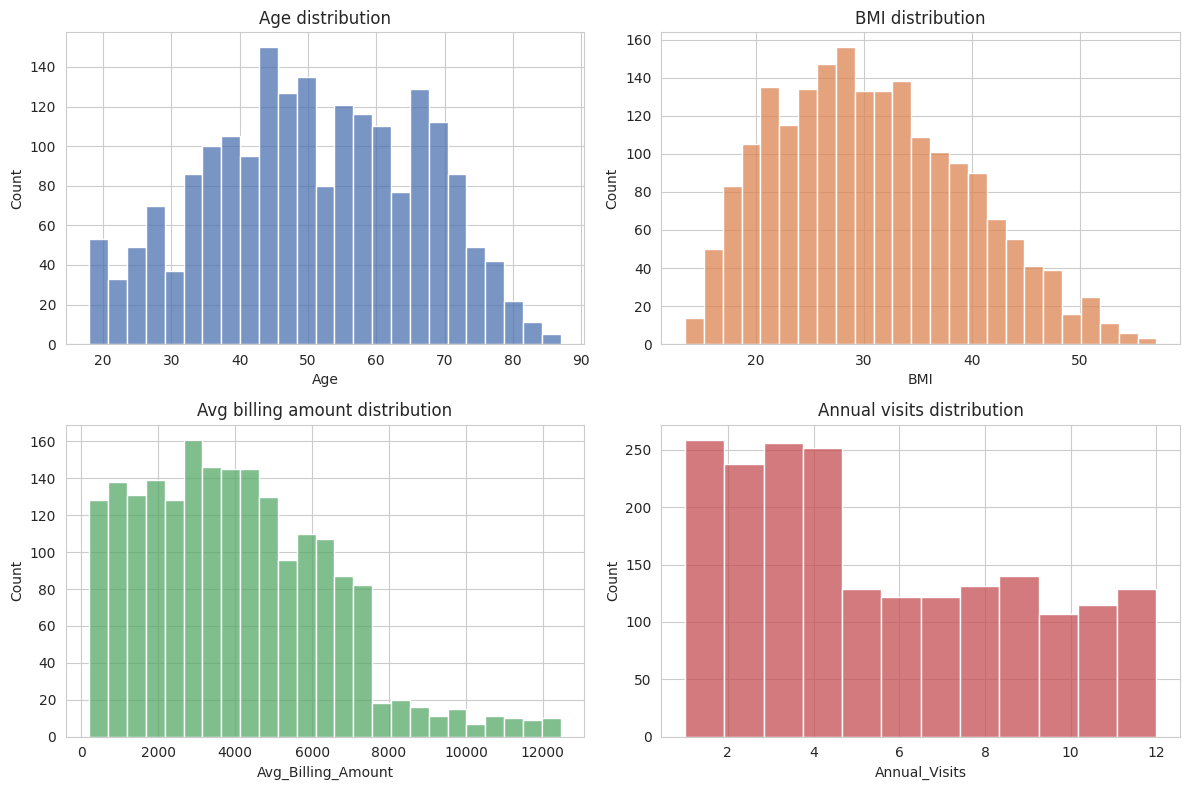

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["Age"], bins=25, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Age distribution")

sns.histplot(df["BMI"], bins=25, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("BMI distribution")

sns.histplot(df["Avg_Billing_Amount"], bins=25, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Avg billing amount distribution")

sns.histplot(df["Annual_Visits"], bins=12, ax=axes[1, 1], color="#C44E52")
axes[1, 1].set_title("Annual visits distribution")

plt.tight_layout()
plt.show()

## 4. Correlation between numeric features

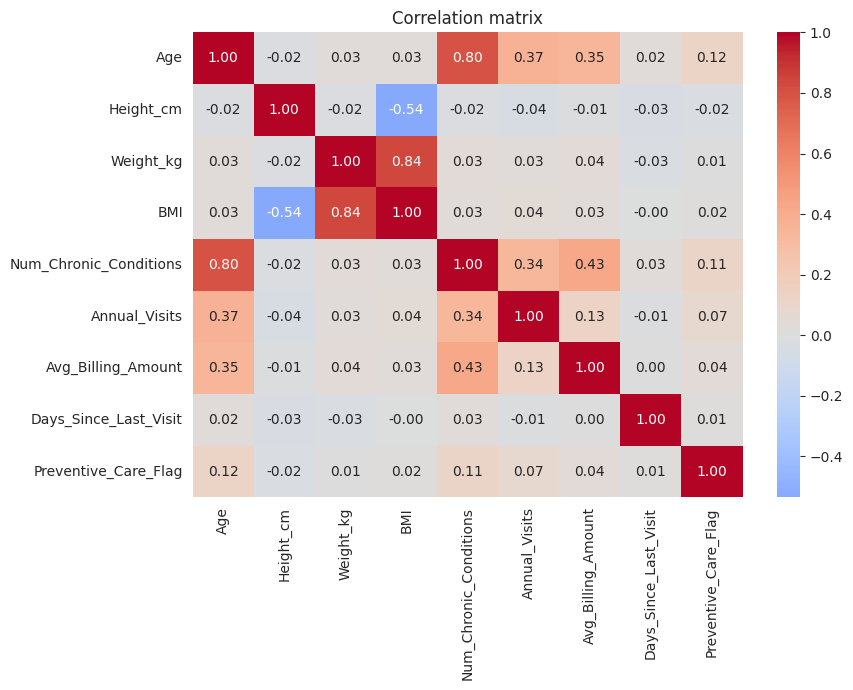

In [7]:
numeric_cols = ["Age", "Height_cm", "Weight_kg", "BMI", "Num_Chronic_Conditions",
                "Annual_Visits", "Avg_Billing_Amount", "Days_Since_Last_Visit",
                "Preventive_Care_Flag"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

No pair of features is strongly correlated, which is expected — this is
synthetic demographic/behavioral data, not a dataset engineered to have obvious
redundancy. This also explains why clustering on it doesn't produce razor-sharp
separated groups later on.

## 5. Billing amount by insurance type

/tmp/ipykernel_559/3441124001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Insurance_Type", y="Avg_Billing_Amount", palette="Set2")


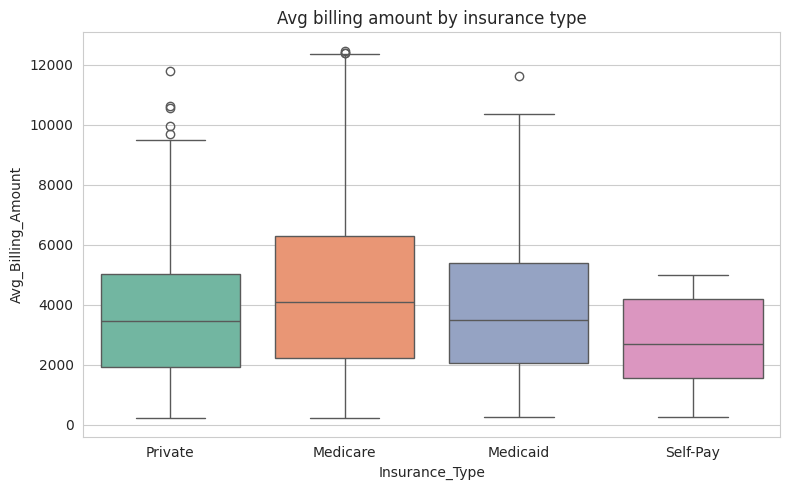

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Insurance_Type", y="Avg_Billing_Amount", palette="Set2")
plt.title("Avg billing amount by insurance type")
plt.tight_layout()
plt.show()

## 6. Feature engineering

Same logic as `src/feature_engineering.py`: a simple point-based risk score,
a BMI category, and cost per visit.

In [9]:
def bmi_points(bmi):
    if bmi >= 30:
        return 20
    if bmi >= 25:
        return 10
    return 0

def age_points(age):
    if age >= 60:
        return 15
    if age >= 40:
        return 5
    return 0

df["Primary_Condition"] = df["Primary_Condition"].fillna("Normal")

chronic_part = df["Num_Chronic_Conditions"] * 20
bmi_part = df["BMI"].apply(bmi_points)
age_part = df["Age"].apply(age_points)
preventive_bonus = df["Preventive_Care_Flag"] * 10

df["Risk_Score"] = (chronic_part + bmi_part + age_part - preventive_bonus).clip(lower=0)
df["Cost_Per_Visit"] = (df["Avg_Billing_Amount"] / df["Annual_Visits"].replace(0, 1)).round(2)

df[["Age", "BMI", "Num_Chronic_Conditions", "Risk_Score", "Cost_Per_Visit"]].describe()

,Age,BMI,Num_Chronic_Conditions,Risk_Score,Cost_Per_Visit
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,50.69550,30.740650,1.080000,36.302500,1241.865720
std,15.44445,8.839952,0.890504,24.220535,1476.797121
min,18.00000,13.400000,0.000000,0.000000,26.120000
25%,40.00000,23.800000,1.000000,20.000000,395.125000
50%,51.00000,30.100000,1.000000,35.000000,745.780000
75%,63.25000,37.025000,1.000000,45.000000,1435.875000
max,87.00000,57.100000,3.000000,95.000000,12165.000000


## 7. Preprocessing for clustering

Scale the numeric behavioral/demographic features and one-hot encode gender
and BMI category. High-cardinality columns (`State`, `Insurance_Type`,
`Primary_Condition`) are kept out of the clustering features themselves —
they add sparse noise without much behavioral signal — but they're kept
around for interpreting the clusters afterward.

In [10]:
feature_cols = ["Age", "Height_cm", "Weight_kg", "BMI", "Num_Chronic_Conditions",
                "Annual_Visits", "Avg_Billing_Amount", "Days_Since_Last_Visit",
                "Preventive_Care_Flag", "Risk_Score", "Cost_Per_Visit"]

X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(2000, 11)

## 8. Choosing k: elbow method and silhouette score

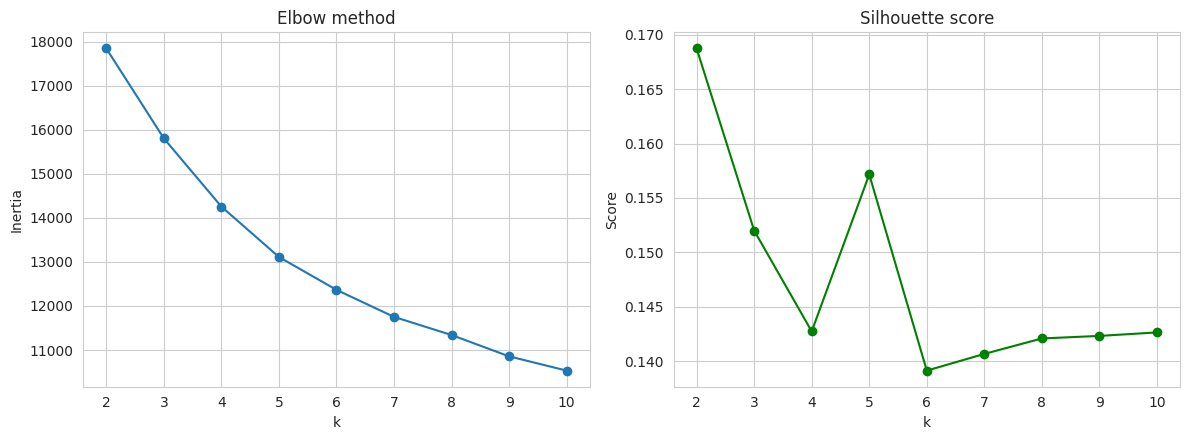

In [11]:
k_values = list(range(2, 11))
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

Silhouette scores are modest across every k (roughly 0.13–0.18) and the
curve is fairly flat. That's a real finding about this dataset, not a mistake:
patient behavior here varies more like a continuum than in sharply separated
clusters — which is common for demographic/behavioral data. The statistical
"best" k by silhouette alone tends to be a low number almost by default in
flat cases like this, so k is chosen for business usefulness (four
distinguishable, actionable patient tiers) rather than blindly maximizing the
score. k=4 is used in the production pipeline.

## 9. Fit the final model with k=4

In [12]:
final_k = 4
model = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X_scaled)
df["Cluster"].value_counts().sort_index()

Cluster
0    510
1    372
2    576
3    542
Name: count, dtype: int64

## 10. Profile each cluster

In [13]:
profile = df.groupby("Cluster").agg(
    patients=("Age", "count"),
    avg_age=("Age", "mean"),
    avg_bmi=("BMI", "mean"),
    avg_risk_score=("Risk_Score", "mean"),
    avg_annual_visits=("Annual_Visits", "mean"),
    avg_billing=("Avg_Billing_Amount", "mean"),
).round(1)

profile = profile.sort_values("avg_risk_score", ascending=False)
profile

,patients,avg_age,avg_bmi,avg_risk_score,avg_annual_visits,avg_billing
Cluster,,,,,,
1,372,68.8,31.5,74.2,5.8,6233.9
3,542,49.8,40.5,39.6,5.8,3736.0
2,576,55.5,24.6,31.0,7.7,3852.5
0,510,33.0,26.8,11.0,2.4,2818.8


Ranking clusters by average risk score gives four clearly ordered tiers —
this is the same rank-based labeling approach used in
`src/cluster_interpretation.py` to avoid two clusters accidentally landing on
the same label.

## 11. Visualize the clusters with PCA

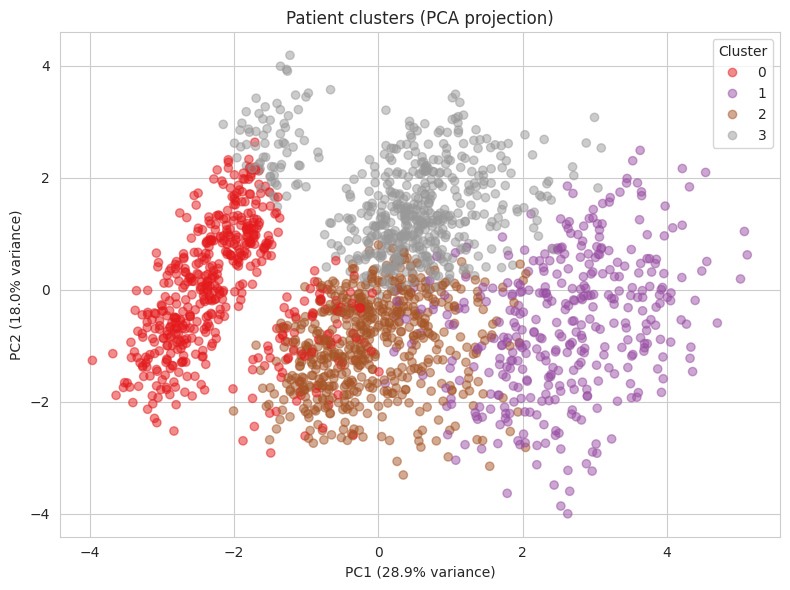

In [14]:
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(components[:, 0], components[:, 1], c=df["Cluster"], cmap="Set1", alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Patient clusters (PCA projection)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

The two components only capture a modest share of the total variance,
which matches the modest silhouette scores above — the clusters overlap more
than they'd separate in a dataset engineered to have obvious groupings. This
is expected and worth stating plainly in a project write-up rather than
implying the segments are more distinct than they are.

## 12. Summary

- 2,000 patients, no true duplicates, one intentionally-missing column that
  turned out to be meaningful rather than an error
- Four segments, ranked by risk score: **Highest Risk**, **High Risk**,
  **Moderate Risk**, **Low Risk**
- Cluster separation is moderate, not sharp — appropriate framing for a
  behavioral/demographic dataset without built-in ground-truth groups
- This notebook mirrors the logic in `src/feature_engineering.py`,
  `src/preprocessing.py`, and `src/clustering.py` — see those for the
  production version with full error handling, and `run_pipeline.py` to run
  the whole thing end to end including the MySQL load.
